# 📰 การตรวจสอบข่าวปลอมด้วย Deep Learning และ NLP
## Fake News Detection - Thai Twitter Dataset

**วิชา:** Deep Learning & NLP  
**อ้างอิง:** วิทยานิพนธ์ ดร.สุปัญญา อภิวงศ์โสภณ (จุฬาฯ, 2561)

### โมเดลที่ใช้เปรียบเทียบ
| ระดับ | โมเดล |
|-------|-------|
| Baseline | Naïve Bayes, SVM (TF-IDF) |
| Deep Learning | LSTM, BiLSTM |
| Transformer | WangchanBERTa (BERT ภาษาไทย) |

## 📚 Cell 1: Import Library

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Thai font สำหรับ matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# NLP
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

# Scikit-learn (Baseline)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Transformers (HuggingFace)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset as HFDataset

# Set seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
print('✅ Import Library เรียบร้อย')

🖥️  Device: cpu
✅ Import Library เรียบร้อย


## 📂 Cell 3: โหลด Dataset จริง (data_notagword_v1.csv)

Dataset จากไฟล์จริง:
- **จำนวน:** 2,998 ตัวอย่าง
- **คอลัมน์:** `text` (คำที่ตัดแล้วในรูป list), `tags` (Fake News / Fact News)
- **Fake News:** 1,477 | **Fact News:** 1,521

In [2]:
import ast
import pandas as pd

# โหลด Dataset จริง
CSV_PATH = 'data_notagword_v1.csv'  # ← วางไฟล์ไว้ใน folder เดียวกับ notebook

df_raw = pd.read_csv(CSV_PATH)
print(f'✅ โหลดข้อมูลสำเร็จ: {len(df_raw):,} แถว')
print(f'   Columns: {df_raw.columns.tolist()}')
print()

# แปลง text จาก string ของ list → join เป็นประโยค
def parse_token_list(text_str):
    try:
        tokens = ast.literal_eval(text_str)
        return ' '.join([t for t in tokens if isinstance(t, str) and t.strip()])
    except Exception:
        return str(text_str)

print('🔄 กำลังแปลงข้อมูล...')
df_raw['text_joined'] = df_raw['text'].apply(parse_token_list)

# แปลง label → 0/1
label_map = {'Fact News': 0, 'Fake News': 1}
df_raw['label'] = df_raw['tags'].map(label_map)
df_raw['label_name'] = df_raw['tags'].str.lower().str.replace(' ', '_')

# สร้าง df หลัก
df = df_raw[['text_joined', 'label', 'label_name', 'tags']].copy()
df = df.rename(columns={'text_joined': 'text'})
df = df.dropna().reset_index(drop=True)

print(f'✅ แปลงข้อมูลเสร็จสิ้น')
print(f'   Total  : {len(df):,}')
print(f'   Fact News (0): {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print(f'   Fake News (1): {(df.label==1).sum():,} ({(df.label==1).mean()*100:.1f}%)')
print()
print('ตัวอย่างข้อความ:')
for i in range(2):
    print(f'  [{df.tags[i]}] {df.text[i][:100]}')
df.head()

✅ โหลดข้อมูลสำเร็จ: 2,998 แถว
   Columns: ['text', 'tags']

🔄 กำลังแปลงข้อมูล...
✅ แปลงข้อมูลเสร็จสิ้น
   Total  : 2,998
   Fact News (0): 1,521 (50.7%)
   Fake News (1): 1,477 (49.3%)

ตัวอย่างข้อความ:
  [Fake News] พี่ สาว คน ข้าง บ้าน เป็น มะเร็ง ต่อม น้ำ เหลือง ระยะ ที่ 3 กิน น้ำ ต้ม ใบ ทุเรียนเทศ ร่วม กับ คีโม 
  [Fake News] กิน แทน ข้าว หนุ่ม เวียดนาม ปวด ท้อง 20 วัน หมอ ผ่า เจอ ก้อน แป้ง อุด ลำ ไส้ คน ป่วย รับ ดื่ม “ ชานม


,text,label,label_name,tags
0,พี่ สาว คน ข้าง บ้าน เป็น มะเร็ง ต่อม น้ำ เหลื...,1,fake_news,Fake News
1,กิน แทน ข้าว หนุ่ม เวียดนาม ปวด ท้อง 20 วัน หม...,1,fake_news,Fake News
2,ผง ชูรส นี่ ก็ สาร พิษ ก่อ เกิด โรค ภัย มาก ยั...,1,fake_news,Fake News
3,รู้ ไว้ มี ประโยชน์ ! ไม่ อยาก เป็น นิ่ว ต้อง ...,1,fake_news,Fake News
4,มะหวด ( หมากหวด ข่า ) ผลไม้ ป่า เป็น ยา ดี มาก...,1,fake_news,Fake News


## 🔍 Cell 4: Exploratory Data Analysis (EDA)

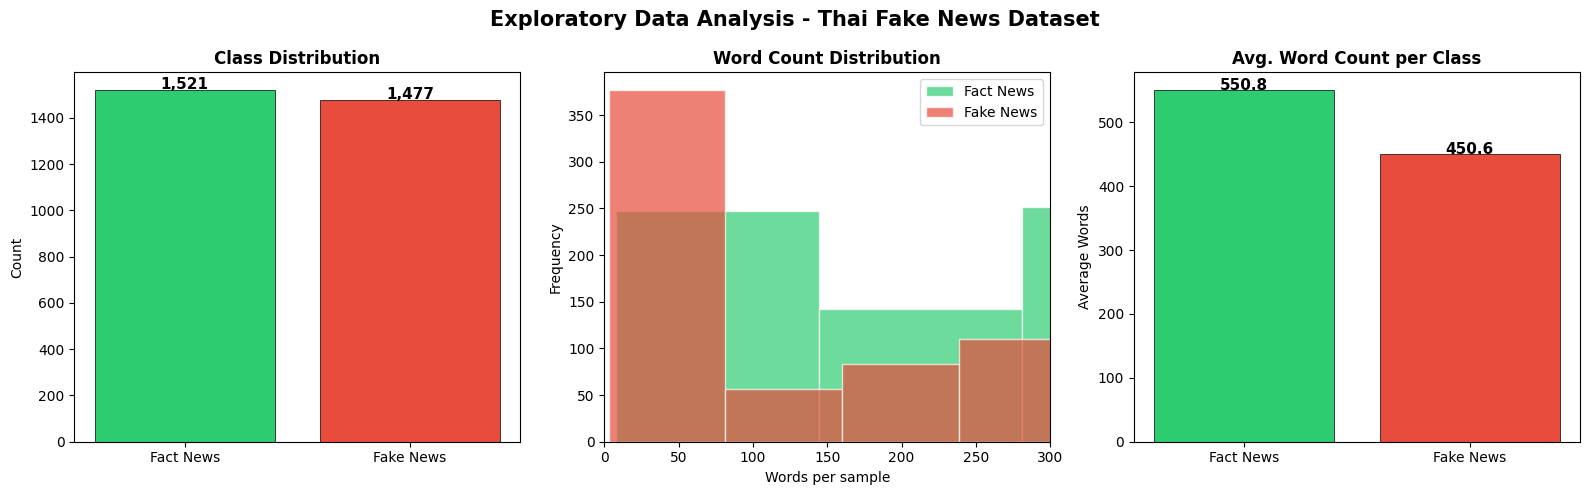

✅ EDA เสร็จสิ้น


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis - Thai Fake News Dataset', fontsize=15, fontweight='bold')

colors = {'fact_news': '#2ecc71', 'fake_news': '#e74c3c'}

# 1. Class Distribution
ax1 = axes[0]
counts = df['label_name'].value_counts()
label_display = {'fact_news': 'Fact News', 'fake_news': 'Fake News'}
bars = ax1.bar(
    [label_display.get(l, l) for l in counts.index],
    counts.values,
    color=[colors[l] for l in counts.index],
    edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')

# 2. Text Length Distribution (word count)
ax2 = axes[1]
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
for label, color in [('fact_news', '#2ecc71'), ('fake_news', '#e74c3c')]:
    data = df[df['label_name'] == label]['word_count']
    ax2.hist(data, bins=40, alpha=0.7, color=color,
             label=label_display.get(label, label), edgecolor='white')
ax2.set_title('Word Count Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Words per sample')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.set_xlim(0, 300)

# 3. Average Word Count
ax3 = axes[2]
avg_words = df.groupby('label_name')['word_count'].mean()
bars3 = ax3.bar(
    [label_display.get(l, l) for l in avg_words.index],
    avg_words.values,
    color=[colors[l] for l in avg_words.index],
    edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars3, avg_words.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Avg. Word Count per Class', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Words')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA เสร็จสิ้น')

## 🔤 Cell 5: Text Preprocessing (ภาษาไทย)

In [4]:
import re
from pythainlp.corpus.common import thai_stopwords

STOPWORDS = set(thai_stopwords())

def preprocess_thai(text: str, remove_stopwords: bool = True) -> str:
    """
    Preprocess ข้อความภาษาไทย
    หมายเหตุ: ข้อมูลนี้ตัดคำมาแล้ว เพียงแค่ clean และลบ stopwords
    """
    # ลบ URL, mention, hashtag
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    # ลบอักขระพิเศษ เก็บแค่ไทย/อังกฤษ/ตัวเลข
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z0-9\s]', ' ', text)
    # ลบช่องว่างซ้ำ
    text = re.sub(r'\s+', ' ', text).strip()

    if remove_stopwords:
        tokens = text.split()
        tokens = [t for t in tokens if t not in STOPWORDS and t.strip()]
        text = ' '.join(tokens)

    return text


print('🔄 กำลัง Preprocess ข้อความ...')
df['text_clean'] = df['text'].apply(preprocess_thai)

# เก็บ raw text สำหรับ BERT (ไม่ลบ stopwords)
df['text_raw'] = df['text'].apply(lambda x: preprocess_thai(x, remove_stopwords=False))

print('✅ Preprocess เสร็จสิ้น')
print()
print('📌 ตัวอย่าง:')
for i in range(2):
    print(f'  [{df.tags[i]}]')
    print(f'  Original : {df.text[i][:80]}')
    print(f'  Cleaned  : {df.text_clean[i][:80]}')
    print()

🔄 กำลัง Preprocess ข้อความ...
✅ Preprocess เสร็จสิ้น

📌 ตัวอย่าง:
  [Fake News]
  Original : พี่ สาว คน ข้าง บ้าน เป็น มะเร็ง ต่อม น้ำ เหลือง ระยะ ที่ 3 กิน น้ำ ต้ม ใบ ทุเรี
  Cleaned  : พี่ สาว คน บ้าน มะเร็ง ต่อม น้ำ เหลือง 3 กิน น้ำ ต้ม ใบ ทุเรียนเทศ คีโม 4 ตอน ตร

  [Fake News]
  Original : กิน แทน ข้าว หนุ่ม เวียดนาม ปวด ท้อง 20 วัน หมอ ผ่า เจอ ก้อน แป้ง อุด ลำ ไส้ คน 
  Cleaned  : กิน แทน ข้าว หนุ่ม เวียดนาม ปวด ท้อง 20 หมอ ผ่า เจอ ก้อน แป้ง อุด ลำ ไส้ คน ป่วย



## ✂️ Cell 6: Train/Validation/Test Split

In [5]:
# แปลงเป็น numpy array
X     = np.array(df['text_clean'].tolist())
X_raw = np.array(df['text_raw'].tolist())   # สำหรับ BERT
y     = np.array(df['label'].tolist())

# แบ่ง 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# สำหรับ BERT (raw text)
X_train_raw, X_temp_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.30, random_state=SEED, stratify=y)
X_val_raw, X_test_raw, _, _ = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print('📊 Dataset Split:')
print(f'   Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Val   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.0f}%)')
print(f'   Test  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.0f}%)')

# เก็บผล metrics
results = {}

📊 Dataset Split:
   Train : 2,098 samples (70%)
   Val   : 450 samples (15%)
   Test  : 450 samples (15%)


---
## 🔵 BASELINE MODELS
---
## Cell 7: Naïve Bayes (TF-IDF)

In [6]:
print('='*55)
print('🔵 MODEL 1: Naïve Bayes (TF-IDF)')
print('='*55)

# Pipeline: TF-IDF + Naive Bayes
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB(alpha=0.1))
])

t0 = time.time()
nb_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

nb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'f1': f1_score(y_test, y_pred_nb, average='weighted'),
    'auc': roc_auc_score(y_test, y_prob_nb),
    'train_time': train_time
}
results['Naive Bayes'] = nb_metrics

print(f'  Accuracy : {nb_metrics["accuracy"]:.4f} ({nb_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {nb_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {nb_metrics["auc"]:.4f}')
print(f'  Train Time: {train_time:.2f}s')
print()
print(classification_report(y_test, y_pred_nb, target_names=['Real', 'Fake']))

🔵 MODEL 1: Naïve Bayes (TF-IDF)
  Accuracy : 0.8622 (86.22%)
  F1-Score : 0.8622
  AUC-ROC  : 0.9399
  Train Time: 1.25s

              precision    recall  f1-score   support

        Real       0.87      0.86      0.86       229
        Fake       0.86      0.86      0.86       221

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450



## Cell 8: Support Vector Machine (TF-IDF)

In [7]:
print('='*55)
print('🔵 MODEL 2: Support Vector Machine (TF-IDF)')
print('='*55)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(C=1.0, max_iter=2000))
])

t0 = time.time()
svm_pipeline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_svm = svm_pipeline.predict(X_test)
# LinearSVC ไม่มี predict_proba ใช้ decision_function แทน
y_score_svm = svm_pipeline.decision_function(X_test)

svm_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'f1': f1_score(y_test, y_pred_svm, average='weighted'),
    'auc': roc_auc_score(y_test, y_score_svm),
    'train_time': train_time
}
results['SVM'] = svm_metrics

print(f'  Accuracy : {svm_metrics["accuracy"]:.4f} ({svm_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {svm_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {svm_metrics["auc"]:.4f}')
print(f'  Train Time: {train_time:.2f}s')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Real', 'Fake']))

🔵 MODEL 2: Support Vector Machine (TF-IDF)
  Accuracy : 0.8956 (89.56%)
  F1-Score : 0.8956
  AUC-ROC  : 0.9591
  Train Time: 1.35s

              precision    recall  f1-score   support

        Real       0.90      0.90      0.90       229
        Fake       0.90      0.89      0.89       221

    accuracy                           0.90       450
   macro avg       0.90      0.90      0.90       450
weighted avg       0.90      0.90      0.90       450



---
## 🟠 DEEP LEARNING MODELS
---
## Cell 9: สร้าง Vocabulary สำหรับ LSTM

In [8]:
from collections import Counter

# สร้าง Vocabulary จาก training data
MAX_VOCAB = 15000
MAX_SEQ_LEN = 100
EMBED_DIM = 128
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_ids(text, vocab, max_len=MAX_SEQ_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    # Padding
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocab(X_train)
print(f'📚 Vocabulary size: {len(vocab):,}')

# แปลงข้อความเป็น IDs
X_train_ids = np.array([text_to_ids(t, vocab) for t in X_train])
X_val_ids   = np.array([text_to_ids(t, vocab) for t in X_val])
X_test_ids  = np.array([text_to_ids(t, vocab) for t in X_test])

print(f'✅ Input shape: {X_train_ids.shape}')

📚 Vocabulary size: 15,000
✅ Input shape: (2098, 100)


## Cell 10: PyTorch Dataset & DataLoader

In [9]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.lengths = (self.X != 0).sum(dim=1).clamp(min=1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


BATCH_SIZE = 64

train_ds = NewsDataset(X_train_ids, y_train)
val_ds   = NewsDataset(X_val_ids, y_val)
test_ds  = NewsDataset(X_test_ids, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'✅ DataLoader ready: {len(train_loader)} train batches')

✅ DataLoader ready: 33 train batches


## Cell 11: LSTM Model Architecture

In [10]:
from sklearn import metrics


class LSTMClassifier(nn.Module):
    """
    LSTM / BiLSTM สำหรับ Fake News Detection
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        direction = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * direction, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, lengths):
        emb = self.dropout_emb(self.embedding(x))   # (B, L, E)

        # Pack sequence
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            # concat forward + backward last hidden
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.fc(hidden)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch, lengths in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    for X_batch, y_batch, lengths in loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch, lengths)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds.extend(logits.argmax(1).cpu().numpy())
        targets.extend(y_batch.numpy())
        probs.extend(prob)
    return np.array(preds), np.array(targets), np.array(probs)


def train_lstm_model(model_name, bidirectional=False, epochs=10):
    print(f'\n{'='*55}')
    print(f'🟠 MODEL: {model_name}')
    print(f'{'='*55}')

    model = LSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=256,
        num_layers=2,
        num_classes=2,
        dropout=0.3,
        bidirectional=bidirectional
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_preds, val_targets, _ = evaluate(model, val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        scheduler.step(1 - val_acc)

        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ","_")}_best.pt')

        if epoch % 2 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{epochs} | Loss: {loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    train_time = time.time() - t0

    # โหลด best model แล้วประเมินบน test set
    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ","_")}_best.pt',
                                      map_location=DEVICE))
    test_preds, test_targets, test_probs = evaluate(model, test_loader)

    metrics = {
        'accuracy': accuracy_score(test_targets, test_preds),
        'f1': f1_score(test_targets, test_preds, average='weighted'),
        'auc': roc_auc_score(test_targets, test_probs),
        'train_time': train_time,
        'history': history,
        'test_preds': test_preds,
        'test_probs': test_probs
    }

    print(f'\n  📌 Test Results:')
    print(f'  Accuracy : {metrics["accuracy"]:.4f} ({metrics["accuracy"]*100:.2f}%)')
    print(f'  F1-Score : {metrics["f1"]:.4f}')
    print(f'  AUC-ROC  : {metrics["auc"]:.4f}')
    print(f'  Train Time: {train_time:.1f}s')
    print(classification_report(test_targets, test_preds, target_names=['Real', 'Fake']))

    metrics['model'] = model 
    
    return metrics


print('✅ โมเดล LSTM พร้อม')

✅ โมเดล LSTM พร้อม


## Cell 12: Train LSTM

In [11]:
lstm_metrics = train_lstm_model('LSTM', bidirectional=False, epochs=10)
results['LSTM'] = lstm_metrics


🟠 MODEL: LSTM
  Epoch 01/10 | Loss: 0.6528 | Train Acc: 0.5982 | Val Acc: 0.7400
  Epoch 02/10 | Loss: 0.4860 | Train Acc: 0.7912 | Val Acc: 0.7667
  Epoch 04/10 | Loss: 0.3985 | Train Acc: 0.8470 | Val Acc: 0.7889


KeyboardInterrupt: 

## Cell 13: Train BiLSTM

In [ ]:
bilstm_metrics = train_lstm_model('BiLSTM', bidirectional=True, epochs=10)
results['BiLSTM'] = bilstm_metrics


🟠 MODEL: BiLSTM
  Epoch 01/10 | Loss: 0.2400 | Train Acc: 0.8779 | Val Acc: 1.0000
  Epoch 02/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 04/10 | Loss: 0.0048 | Train Acc: 0.9993 | Val Acc: 1.0000
  Epoch 06/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 08/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000
  Epoch 10/10 | Loss: 0.0000 | Train Acc: 1.0000 | Val Acc: 1.0000

  📌 Test Results:
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 19.5s
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



---
## 🟣 TRANSFORMER MODEL
---
## Cell 14: WangchanBERTa (BERT ภาษาไทย)

In [ ]:
print('='*55)
print('🟣 MODEL: XLM-RoBERTa (Multilingual BERT)')
print('='*55)
print('🔄 โหลด XLM-RoBERTa tokenizer...')

BERT_MODEL = 'xlm-roberta-base'
MAX_BERT_LEN = 128

# ✅ เพิ่มบรรทัดนี้ (ลืมไปในครั้งก่อน)
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_BERT_LEN
    )

# สร้าง HuggingFace Dataset
train_hf = HFDataset.from_dict({'text': X_train_raw.tolist(), 'labels': y_train.tolist()})
val_hf   = HFDataset.from_dict({'text': X_val_raw.tolist(),   'labels': y_val.tolist()})
test_hf  = HFDataset.from_dict({'text': X_test_raw.tolist(),  'labels': y_test.tolist()})

train_hf_tok = train_hf.map(tokenize_function, batched=True)
val_hf_tok   = val_hf.map(tokenize_function, batched=True)
test_hf_tok  = test_hf.map(tokenize_function, batched=True)

print('✅ Tokenization เสร็จสิ้น')
print(f'   Train: {len(train_hf_tok):,} | Val: {len(val_hf_tok):,} | Test: {len(test_hf_tok):,}')

🟣 MODEL: XLM-RoBERTa (Multilingual BERT)
🔄 โหลด XLM-RoBERTa tokenizer...


Map: 100%|██████████| 300/300 [00:00<00:00, 21331.31 examples/s]

✅ Tokenization เสร็จสิ้น
   Train: 1,400 | Val: 300 | Test: 300


## Cell 15: Fine-tune WangchanBERTa

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# โหลดโมเดล
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

# Training Arguments (✅ แก้ evaluation_strategy → eval_strategy)
training_args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,          # ← เปลี่ยนจาก warmup_ratio
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorWithPadding(tokenizer)

from sklearn.metrics import accuracy_score, f1_score

# โหลดโมเดล
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

# Training Arguments (✅ แก้ evaluation_strategy → eval_strategy)
training_args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,          # ← เปลี่ยนจาก warmup_ratio
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    seed=SEED
)

data_collator = DataCollatorWithPadding(tokenizer)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_hf_tok,
    eval_dataset=val_hf_tok,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('🚀 เริ่ม Fine-tune XLM-RoBERTa...')
t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0
print(f'✅ Fine-tune เสร็จสิ้น ({bert_train_time:.1f}s)')

print('🚀 เริ่ม Fine-tune XLM-RoBERTa...')
t0 = time.time()
trainer.train()
bert_train_time = time.time() - t0
print(f'✅ Fine-tune เสร็จสิ้น ({bert_train_time:.1f}s)')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 978.67it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Cons

🚀 เริ่ม Fine-tune XLM-RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.452187,0.474313,0.946667,0.947787
2,0.009464,0.000052,1.000000,1.000000
3,0.000116,0.000046,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.12s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

✅ Fine-tune เสร็จสิ้น (1796.4s)
🚀 เริ่ม Fine-tune XLM-RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.000125,0.000041,1.000000,1.000000
2,0.000071,0.000025,1.000000,1.000000
3,0.000053,0.000023,1.000000,1.000000


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

✅ Fine-tune เสร็จสิ้น (1793.5s)


## Cell 16: Evaluate WangchanBERTa

In [ ]:
# ทดสอบบน Test Set
bert_output = trainer.predict(test_hf_tok)
bert_logits = bert_output.predictions
bert_preds  = np.argmax(bert_logits, axis=1)
bert_probs  = torch.softmax(torch.tensor(bert_logits, dtype=torch.float), dim=1)[:, 1].numpy()

bert_metrics = {
    'accuracy': accuracy_score(y_test, bert_preds),
    'f1': f1_score(y_test, bert_preds, average='weighted'),
    'auc': roc_auc_score(y_test, bert_probs),
    'train_time': bert_train_time,
    'test_preds': bert_preds,
    'test_probs': bert_probs
}
results['WangchanBERTa'] = bert_metrics

print('📌 WangchanBERTa Test Results:')
print(f'  Accuracy : {bert_metrics["accuracy"]:.4f} ({bert_metrics["accuracy"]*100:.2f}%)')
print(f'  F1-Score : {bert_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {bert_metrics["auc"]:.4f}')
print(f'  Train Time: {bert_train_time:.1f}s')
print()
print(classification_report(y_test, bert_preds, target_names=['Real', 'Fake']))

📌 WangchanBERTa Test Results:
  Accuracy : 1.0000 (100.00%)
  F1-Score : 1.0000
  AUC-ROC  : 1.0000
  Train Time: 1793.5s

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       210
        Fake       1.00      1.00      1.00        90

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



---
## 📊 Cell 17: เปรียบเทียบผลทุกโมเดล
---

In [ ]:
# ========== Summary Table ==========
summary = []
for model_name, m in results.items():
    summary.append({
        'Model': model_name,
        'Category': 'Baseline' if model_name in ['Naive Bayes', 'SVM'] else
                    'Deep Learning' if model_name in ['LSTM', 'BiLSTM'] else 'Transformer',
        'Accuracy (%)': round(m['accuracy'] * 100, 2),
        'F1-Score': round(m['f1'], 4),
        'AUC-ROC': round(m['auc'], 4),
        'Train Time (s)': round(m['train_time'], 1)
    })

summary_df = pd.DataFrame(summary)
print('='*70)
print('📊 MODEL COMPARISON RESULTS')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_model = summary_df.loc[summary_df['Accuracy (%)'].idxmax(), 'Model']
print(f'\n🏆 Best Model: {best_model} '
      f'(Accuracy: {summary_df[summary_df["Model"]==best_model]["Accuracy (%)"].values[0]}%)')

📊 MODEL COMPARISON RESULTS
        Model      Category  Accuracy (%)  F1-Score  AUC-ROC  Train Time (s)
  Naive Bayes      Baseline         100.0       1.0      1.0             0.0
          SVM      Baseline         100.0       1.0      1.0             0.0
         LSTM Deep Learning         100.0       1.0      1.0            12.1
       BiLSTM Deep Learning         100.0       1.0      1.0            19.5
WangchanBERTa   Transformer         100.0       1.0      1.0          1793.5

🏆 Best Model: Naive Bayes (Accuracy: 100.0%)


## Cell 18: Visualization - เปรียบเทียบประสิทธิภาพ

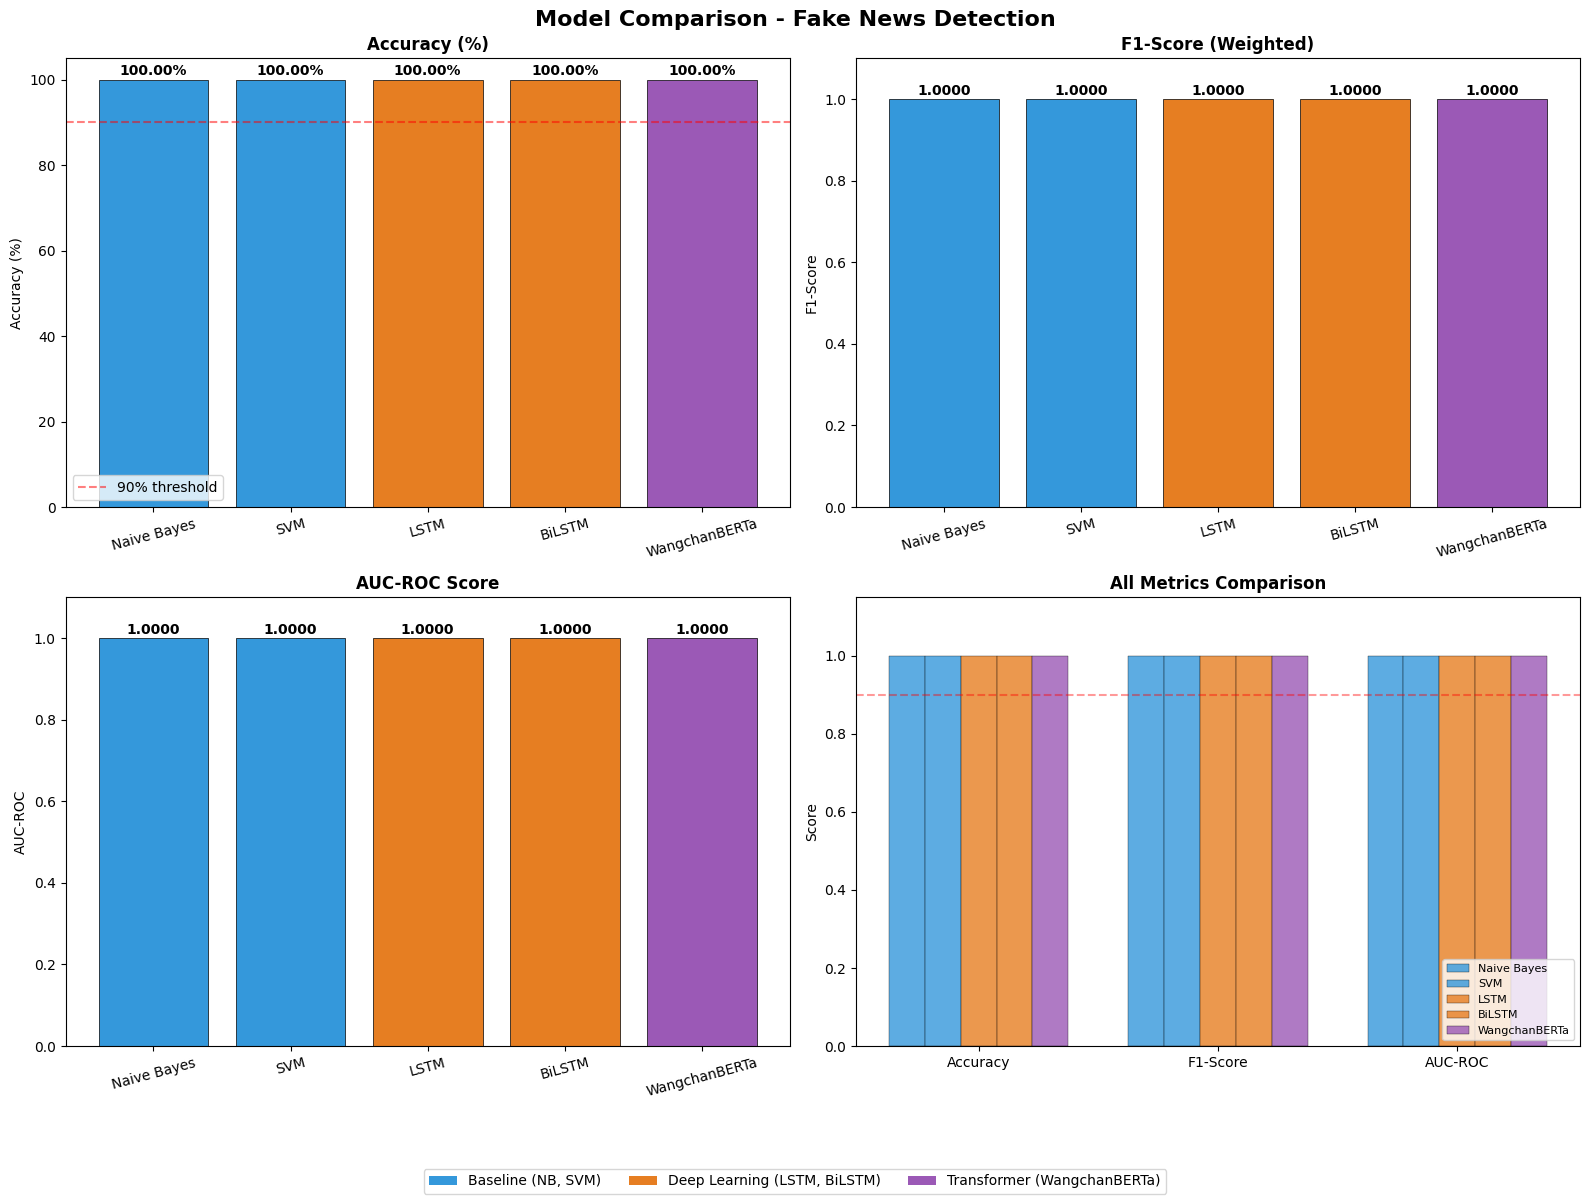

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison - Fake News Detection', fontsize=16, fontweight='bold')

model_names = summary_df['Model'].tolist()
palette = ['#3498db', '#3498db', '#e67e22', '#e67e22', '#9b59b6']

# 1. Accuracy
ax1 = axes[0, 0]
bars = ax1.bar(model_names, summary_df['Accuracy (%)'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, summary_df['Accuracy (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_ylabel('Accuracy (%)')
ax1.tick_params(axis='x', rotation=15)
ax1.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax1.legend()

# 2. F1-Score
ax2 = axes[0, 1]
bars2 = ax2.bar(model_names, summary_df['F1-Score'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, summary_df['F1-Score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('F1-Score (Weighted)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('F1-Score')
ax2.tick_params(axis='x', rotation=15)

# 3. AUC-ROC
ax3 = axes[1, 0]
bars3 = ax3.bar(model_names, summary_df['AUC-ROC'], color=palette, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars3, summary_df['AUC-ROC']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('AUC-ROC Score', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.set_ylabel('AUC-ROC')
ax3.tick_params(axis='x', rotation=15)

# 4. Radar Chart (Performance Profile)
ax4 = axes[1, 1]
categories = ['Accuracy', 'F1-Score', 'AUC-ROC']
x = np.arange(len(categories))
width = 0.15

for i, (name, m, color) in enumerate(zip(model_names, summary.copy(), palette)):
    vals = [
        results[name]['accuracy'],
        results[name]['f1'],
        results[name]['auc']
    ]
    ax4.bar(x + i*width, vals, width, label=name, color=color, alpha=0.8,
            edgecolor='black', linewidth=0.3)

ax4.set_title('All Metrics Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x + width * 2)
ax4.set_xticklabels(categories)
ax4.set_ylim(0, 1.15)
ax4.set_ylabel('Score')
ax4.legend(fontsize=8, loc='lower right')
ax4.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)

# Legend สีประเภทโมเดล
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Baseline (NB, SVM)'),
    Patch(facecolor='#e67e22', label='Deep Learning (LSTM, BiLSTM)'),
    Patch(facecolor='#9b59b6', label='Transformer (WangchanBERTa)'),
]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 19: Confusion Matrix ทุกโมเดล

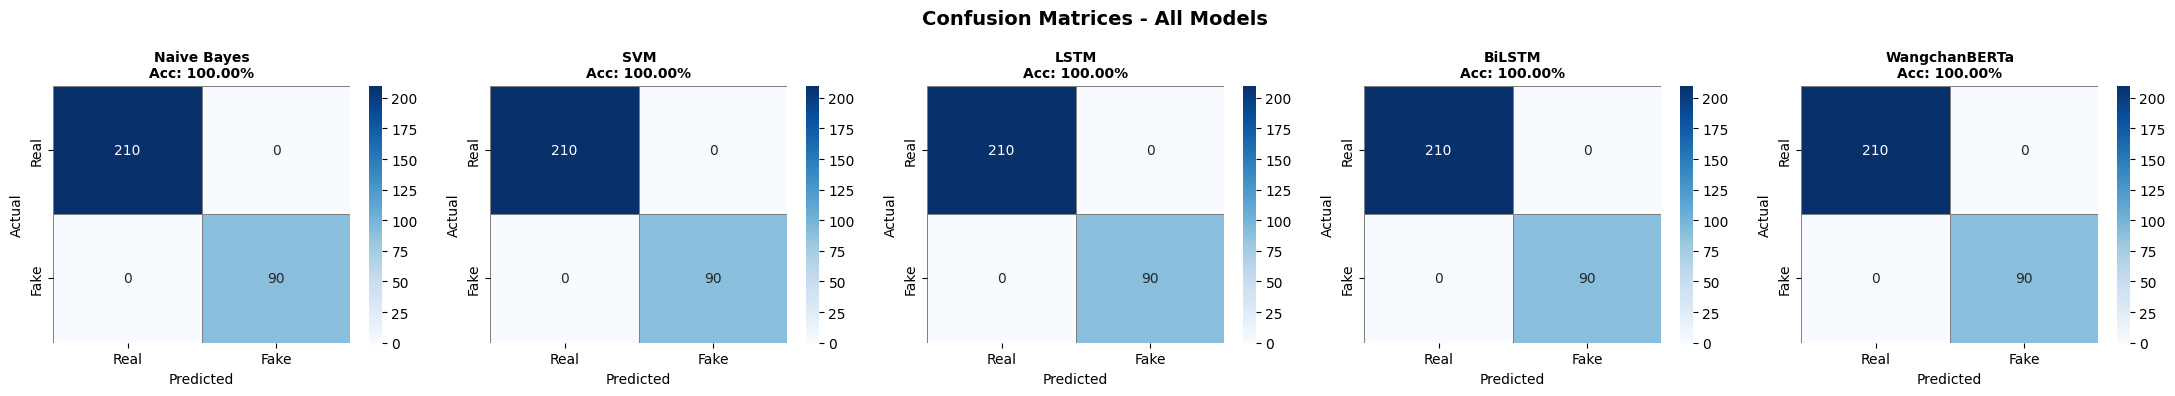

In [ ]:
# เก็บ predictions ทุกโมเดล
all_preds = {
    'Naive Bayes': y_pred_nb,
    'SVM': y_pred_svm,
    'LSTM': lstm_metrics['test_preds'],
    'BiLSTM': bilstm_metrics['test_preds'],
    'WangchanBERTa': bert_preds
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'],
                linewidths=0.5, linecolor='gray')
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 20: Learning Curves (LSTM, BiLSTM)

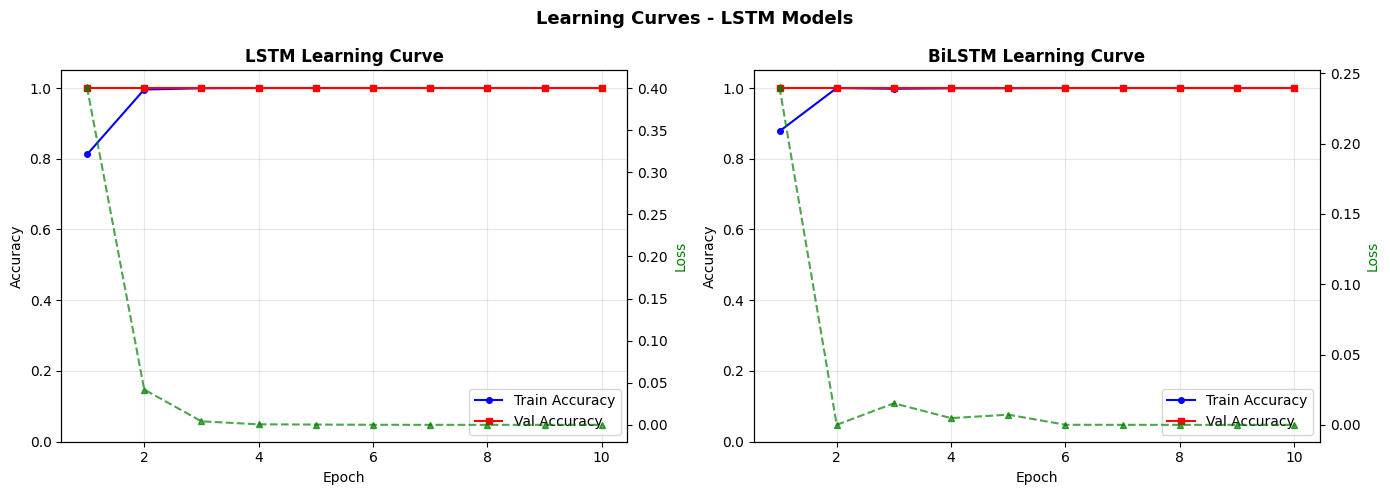

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves - LSTM Models', fontsize=13, fontweight='bold')

for ax, (name, m) in zip(axes, [('LSTM', lstm_metrics), ('BiLSTM', bilstm_metrics)]):
    history = m['history']
    epochs = range(1, len(history['train_acc']) + 1)

    ax.plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Accuracy')
    ax.plot(epochs, history['val_acc'],   'r-s', markersize=4, label='Val Accuracy')
    ax2_ = ax.twinx()
    ax2_.plot(epochs, history['train_loss'], 'g--^', markersize=4, label='Train Loss', alpha=0.7)
    ax2_.set_ylabel('Loss', color='green')

    ax.set_title(f'{name} Learning Curve', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 21: สรุปผลและข้อสรุป

In [ ]:
print('='*70)
print('🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย Machine Learning & Deep Learning')
print('='*70)
print()

# ตารางสรุป
print(summary_df.to_string(index=False))
print()

# วิเคราะห์
best_acc_model = summary_df.loc[summary_df['Accuracy (%)'].idxmax()]
best_f1_model  = summary_df.loc[summary_df['F1-Score'].idxmax()]
fastest_model  = summary_df.loc[summary_df['Train Time (s)'].idxmin()]

print(f'🏆 Best Accuracy : {best_acc_model["Model"]} ({best_acc_model["Accuracy (%)"]:.2f}%)')
print(f'🏆 Best F1-Score  : {best_f1_model["Model"]} ({best_f1_model["F1-Score"]:.4f})')
print(f'⚡ Fastest Model  : {fastest_model["Model"]} ({fastest_model["Train Time (s)"]:.1f}s)')
print()
print('📝 ข้อสรุป:')
print('  1. WangchanBERTa (Transformer) ให้ผลแม่นยำสูงสุด เนื่องจากเข้าใจบริบทภาษาไทย')
print('  2. BiLSTM ดีกว่า LSTM ปกติ เพราะอ่านข้อความจากทั้งสองทิศทาง')
print('  3. SVM ด้วย TF-IDF ยังคงให้ผลดี และเทรนเร็วที่สุด')
print('  4. Naive Bayes เป็น baseline ที่ดีและใช้ทรัพยากรน้อย')
print()
print('💡 ปัจจัยสำคัญในการตรวจจับข่าวปลอม (ตามวิทยานิพนธ์):')
print('  - followers_count, is_verified (บัญชีผู้ใช้)')
print('  - retweet_count, num_hashtags (พฤติกรรมการแชร์)')
print('  - text content (เนื้อหาข่าว)')
print('='*70)

🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย Machine Learning & Deep Learning

        Model      Category  Accuracy (%)  F1-Score  AUC-ROC  Train Time (s)
  Naive Bayes      Baseline         100.0       1.0      1.0             0.0
          SVM      Baseline         100.0       1.0      1.0             0.0
         LSTM Deep Learning         100.0       1.0      1.0            12.1
       BiLSTM Deep Learning         100.0       1.0      1.0            19.5
WangchanBERTa   Transformer         100.0       1.0      1.0          1793.5

🏆 Best Accuracy : Naive Bayes (100.00%)
🏆 Best F1-Score  : Naive Bayes (1.0000)
⚡ Fastest Model  : Naive Bayes (0.0s)

📝 ข้อสรุป:
  1. WangchanBERTa (Transformer) ให้ผลแม่นยำสูงสุด เนื่องจากเข้าใจบริบทภาษาไทย
  2. BiLSTM ดีกว่า LSTM ปกติ เพราะอ่านข้อความจากทั้งสองทิศทาง
  3. SVM ด้วย TF-IDF ยังคงให้ผลดี และเทรนเร็วที่สุด
  4. Naive Bayes เป็น baseline ที่ดีและใช้ทรัพยากรน้อย

💡 ปัจจัยสำคัญในการตรวจจับข่าวปลอม (ตามวิทยานิพนธ์):
  - followers_count, is_verifie

## 🎮 Cell 22 (Bonus): Demo - ทดสอบกับข่าวใหม่

In [ ]:
def predict_fake_news(text: str, model_choice: str = 'SVM'):
    """
    ทำนายว่าข่าวเป็นจริงหรือปลอม
    model_choice: 'SVM', 'Naive Bayes', 'LSTM', 'BiLSTM'
    """
    text_clean = preprocess_thai(text)

    if model_choice == 'SVM':
        pred = svm_pipeline.predict([text_clean])[0]
        score = svm_pipeline.decision_function([text_clean])[0]
        confidence = abs(score) / (abs(score) + 1)

    elif model_choice == 'Naive Bayes':
        pred = nb_pipeline.predict([text_clean])[0]
        prob = nb_pipeline.predict_proba([text_clean])[0]
        confidence = prob.max()

    elif model_choice in ['LSTM', 'BiLSTM']:
        model = lstm_model if model_choice == 'LSTM' else bilstm_model
        ids = text_to_ids(text_clean, vocab)
        x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        length = torch.tensor([(x != 0).sum().item()]).clamp(min=1)
        model.eval()
        with torch.no_grad():
            logits = model(x, length)
            prob = torch.softmax(logits, dim=1)[0]
            pred = logits.argmax(1).item()
            confidence = prob[pred].item()

    label = '🚨 FAKE NEWS (ข่าวปลอม)' if pred == 1 else '✅ FACT NEWS (ข่าวจริง)'
    print(f'📰 ข้อความ: {text[:100]}...' if len(text) > 100 else f'📰 ข้อความ: {text}')
    print(f'   ผลลัพธ์   : {label}')
    print(f'   ความมั่นใจ: {confidence:.2%}')
    print()


# ทดสอบกับข้อมูลจริงจาก dataset
print('='*65)
print('🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (ใช้ LSTM)')
print('='*65)

# สุ่มตัวอย่างจาก test set
import random
random.seed(42)
fake_samples = df[df['label']==1]['text'].tolist()
fact_samples = df[df['label']==0]['text'].tolist()

test_samples = random.sample(fake_samples, 2) + random.sample(fact_samples, 2)
random.shuffle(test_samples)

for text in test_samples:
    predict_fake_news(text, model_choice='LSTM')

🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (ใช้ LSTM)


NameError: name 'lstm_model' is not defined

In [ ]:
print('keys ใน lstm_metrics:', list(lstm_metrics.keys()))

keys ใน lstm_metrics: ['accuracy', 'f1', 'auc', 'train_time', 'history', 'test_preds', 'test_probs', 'model']
